## Section 3: Measures of Position (Relative Standing)

## 1. Percentiles (Division into 100 Equal Parts)

In [1]:
import numpy as np
import statistics
import matplotlib.pyplot as plt
import scipy.stats as stats
import math


Plain Python (Nearest Rank):  95
statistics.quantiles(n=100): 97.40
np.percentile():             95.60
scipy scoreatpercentile():   95.60


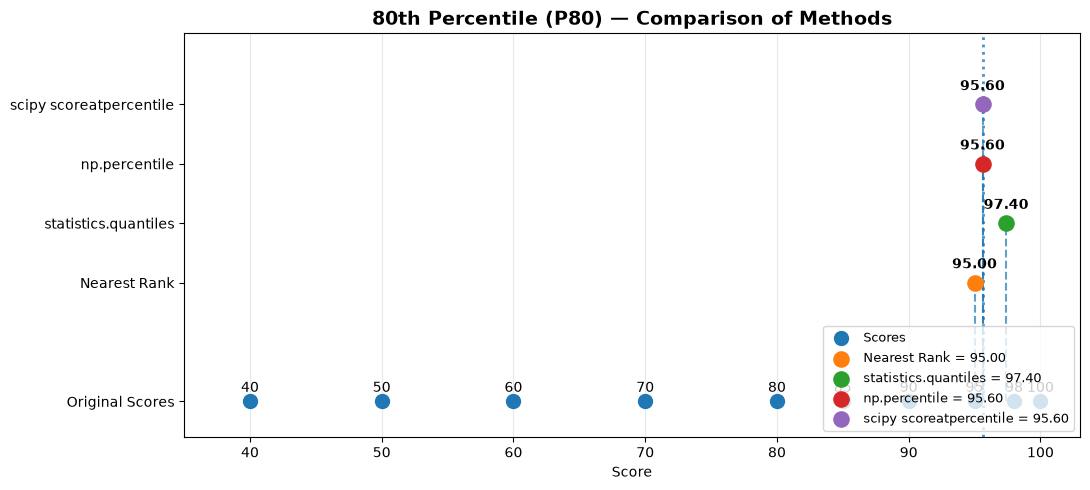

In [2]:
# 1. Percentile Example (80th Percentile)
scores = [40, 50, 60, 70, 80, 85, 90, 95, 98, 100]
p = 80

# Plain Python (Nearest-rank / Interpolation method)
sorted_scores = sorted(scores)
idx = int(np.ceil((p / 100) * len(sorted_scores))) - 1
p80_python = sorted_scores[idx]

# Standard Library (statistics.quantiles - divides into 100 intervals)
# Note: quantiles returns 99 cut points for percentiles
p80_stats = statistics.quantiles(scores, n=100)[79]

# NumPy Library (np.percentile)
p80_np = np.percentile(scores, p)

# SciPy Library (stats.scoreatpercentile)
p80_scipy = stats.scoreatpercentile(scores, p)

print(f"Plain Python (Nearest Rank):  {p80_python}")
print(f"statistics.quantiles(n=100): {p80_stats:.2f}")
print(f"np.percentile():             {p80_np:.2f}")
print(f"scipy scoreatpercentile():   {p80_scipy:.2f}")

fig, ax = plt.subplots(figsize=(11, 5))

# Original scores
y_scores = np.ones(len(scores))

ax.scatter(
    scores,
    y_scores,
    s=100,
    label="Scores",
    zorder=3
)

# Label each score
for score in scores:
    ax.text(
        score,
        1.08,
        str(score),
        ha="center",
        fontsize=10
    )

# P80 values from each method
methods = [
    ("Nearest Rank", p80_python, 2.0),
    ("statistics.quantiles", p80_stats, 2.5),
    ("np.percentile", p80_np, 3.0),
    ("scipy scoreatpercentile", p80_scipy, 3.5)
]

for method, value, y in methods:

    ax.scatter(
        value,
        y,
        s=120,
        zorder=4,
        label=f"{method} = {value:.2f}"
    )

    ax.vlines(
        value,
        1,
        y,
        linestyle="--",
        linewidth=1.5,
        alpha=0.7
    )

    ax.text(
        value,
        y + 0.12,
        f"{value:.2f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# Highlight the 80th percentile position
ax.axvline(
    p80_np,
    linestyle=":",
    linewidth=2,
    alpha=0.8
)

# Formatting
ax.set_xlim(35, 103)
ax.set_ylim(0.7, 4.1)

ax.set_xlabel("Score")
ax.set_yticks([1, 2, 2.5, 3, 3.5])
ax.set_yticklabels([
    "Original Scores",
    "Nearest Rank",
    "statistics.quantiles",
    "np.percentile",
    "scipy scoreatpercentile"
])

ax.set_title(
    "80th Percentile (P80) — Comparison of Methods",
    fontsize=14,
    fontweight="bold"
)

ax.grid(axis="x", alpha=0.3)

ax.legend(
    loc="lower right",
    fontsize=9
)

plt.tight_layout()
plt.show()

## 2. Quartiles & Interquartile Range (Division into 4 Equal Parts)

--- Standard Library (statistics.quantiles) ---
Q1: 4.0, Q2 (Median): 8.0, Q3: 12.0

--- NumPy Library (np.percentile) ---
Q1: 5.0, Q2 (Median): 8.0, Q3: 11.0


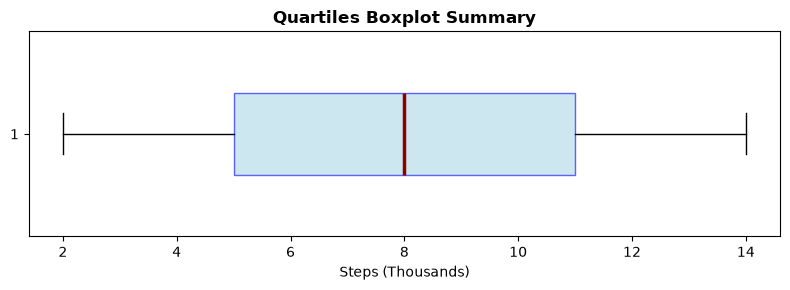

In [3]:
# 2. Quartiles Example
steps = [2, 4, 6, 8, 10, 12, 14]
# Standard Library (statistics.quantiles - splits into 4 parts: Q1, Q2, Q3)
q1_stats, q2_stats, q3_stats = statistics.quantiles(steps, n=4)
# NumPy Library
q1_np, q2_np, q3_np = np.percentile(steps, [25, 50, 75])

print("--- Standard Library (statistics.quantiles) ---")
print(f"Q1: {q1_stats:.1f}, Q2 (Median): {q2_stats:.1f}, Q3: {q3_stats:.1f}")

print("\n--- NumPy Library (np.percentile) ---")
print(f"Q1: {q1_np:.1f}, Q2 (Median): {q2_np:.1f}, Q3: {q3_np:.1f}")
# Visualization using horizontal Boxplot (using non-deprecated orientation parameter)
fig, ax = plt.subplots(figsize=(8, 3))
bp = ax.boxplot(steps, orientation='horizontal', patch_artist=True, widths=0.4,
                boxprops=dict(facecolor='lightblue', color='blue', alpha=0.6),
                medianprops=dict(color='darkred', linewidth=2.5))
ax.set_title("Quartiles Boxplot Summary", fontweight='bold')
ax.set_xlabel("Steps (Thousands)")
plt.tight_layout()
plt.show()

## 3. Z-Score / Standard Score (Distance from Mean in Std Devs)

z_array_scipy:  [-1.45999279 -0.81110711 -0.16222142  0.48666426  1.13554995  0.81110711]
Plain Python Z-Score for x=85:       +0.949
SciPy stats.zscore for x=85:         +0.811
NumPy Z-scores for full dataset:   [-1.26 -0.63  0.    0.63  1.26]


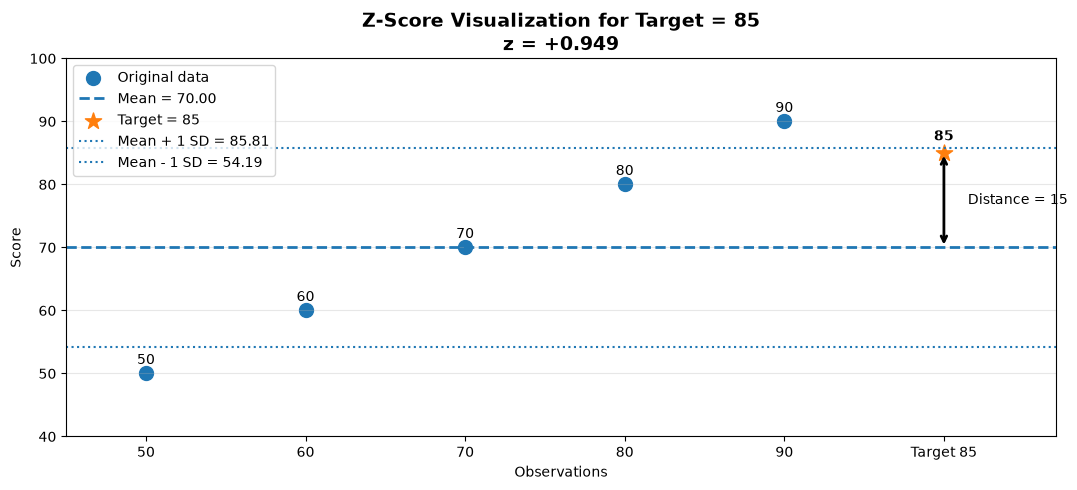

In [6]:
# 3. Z-Score Example
data = [50, 60, 70, 80, 90]
target_val = 85

# Plain Python
mean_val = sum(data) / len(data)
std_val = math.sqrt(sum((x - mean_val) ** 2 for x in data) / (len(data) - 1))
z_python = (target_val - mean_val) / std_val

# SciPy Library (Calculates Z-scores for all elements in array)
# ddof=1 ensures sample standard deviation in denominator
z_array_scipy = stats.zscore(data + [target_val], ddof=1)
print("z_array_scipy: ", z_array_scipy)
z_target_scipy = z_array_scipy[-1]

# NumPy Vectorized Transformation for Entire Dataset
np_data = np.array(data)
z_all_np = (np_data - np.mean(np_data)) / np.std(np_data, ddof=1)

print(f"Plain Python Z-Score for x=85:       {z_python:+.3f}")
print(f"SciPy stats.zscore for x=85:         {z_target_scipy:+.3f}")
print(f"NumPy Z-scores for full dataset:   {np.round(z_all_np, 2)}")

z_target = (target_val - mean_val) / std_val

# -----------------------------
# 3. Create graph
# -----------------------------
fig, ax = plt.subplots(figsize=(11, 5))

# Original data points
x_positions = np.arange(1, len(data) + 1)

ax.scatter(
    x_positions,
    data,
    s=100,
    label="Original data"
)

# Label original values
for x, value in zip(x_positions, data):
    ax.text(
        x,
        value + 1.5,
        str(value),
        ha="center",
        fontsize=10
    )

# Mean horizontal line
ax.axhline(
    mean_val,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_val:.2f}"
)

# Target value
ax.scatter(
    6,
    target_val,
    s=150,
    marker="*",
    label=f"Target = {target_val}"
)

ax.text(
    6,
    target_val + 2,
    f"85",
    ha="center",
    fontweight="bold"
)

# -----------------------------
# 4. Show distance from mean
# -----------------------------
ax.annotate(
    "",
    xy=(6, target_val),
    xytext=(6, mean_val),
    arrowprops=dict(
        arrowstyle="<->",
        linewidth=2
    )
)

# Label the distance
ax.text(
    6.15,
    (mean_val + target_val) / 2,
    f"Distance = {target_val - mean_val:.0f}",
    va="center",
    fontsize=10
)

# -----------------------------
# 5. Show ±1 standard deviation
# -----------------------------
ax.axhline(
    mean_val + std_val,
    linestyle=":",
    linewidth=1.5,
    label=f"Mean + 1 SD = {mean_val + std_val:.2f}"
)

ax.axhline(
    mean_val - std_val,
    linestyle=":",
    linewidth=1.5,
    label=f"Mean - 1 SD = {mean_val - std_val:.2f}"
)

# -----------------------------
# 6. Formatting
# -----------------------------
ax.set_xlim(0.5, 6.7)
ax.set_ylim(40, 100)

ax.set_xticks(
    list(x_positions) + [6]
)

ax.set_xticklabels(
    ["50", "60", "70", "80", "90", "Target 85"]
)

ax.set_ylabel("Score")
ax.set_xlabel("Observations")

ax.set_title(
    f"Z-Score Visualization for Target = 85\n"
    f"z = {z_target:+.3f}",
    fontsize=14,
    fontweight="bold"
)

ax.grid(axis="y", alpha=0.3)
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

## 4. Percentile Rank (Percentage of Scores At or Below a Value)

Plain Python Percentile Rank (x=70): 50.0%
SciPy percentileofscore (kind='mean'): 50.0%
SciPy percentileofscore (kind='strict'): 33.3%


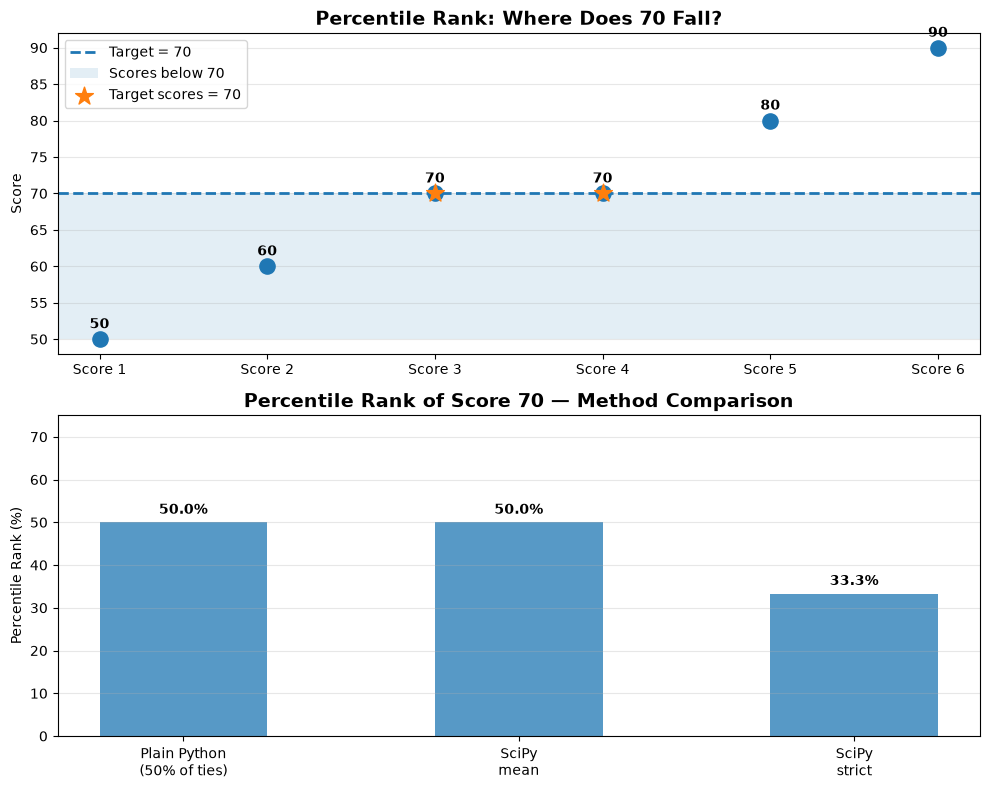

In [9]:
# 4. Percentile Rank Example
scores = [50, 60, 70, 70, 80, 90]
target_score = 70

# Plain Python
count_less = sum(1 for x in scores if x < target_score)
count_equal = sum(1 for x in scores if x == target_score)
pr_python = ((count_less + 0.5 * count_equal) / len(scores)) * 100

# SciPy Library (stats.percentileofscore)
# kind='weak' counts <= target, kind='rank' uses fractional ranking
pr_scipy_strict = stats.percentileofscore(scores, target_score, kind='strict') # strict counts < target
pr_scipy_mean = stats.percentileofscore(scores, target_score, kind='mean')

print(f"Plain Python Percentile Rank (x=70): {pr_python:.1f}%")
print(f"SciPy percentileofscore (kind='mean'): {pr_scipy_mean:.1f}%")
print(f"SciPy percentileofscore (kind='strict'): {pr_scipy_strict:.1f}%")

# =====================================================
# GRAPH 1: Scores and target
# =====================================================

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10, 8)
)

x_positions = np.arange(len(scores))

# Plot all scores
ax1.scatter(
    x_positions,
    scores,
    s=120,
    zorder=3
)

# Label every score
for x, score in zip(x_positions, scores):
    ax1.text(
        x,
        score + 1.5,
        str(score),
        ha='center',
        fontweight='bold'
    )

# Target line
ax1.axhline(
    target_score,
    linestyle='--',
    linewidth=2,
    label='Target = 70'
)

# Shade scores below target
ax1.axhspan(
    min(scores),
    target_score,
    alpha=0.12,
    label='Scores below 70'
)

# Highlight target scores
target_positions = [
    i for i, x in enumerate(scores)
    if x == target_score
]

ax1.scatter(
    target_positions,
    [target_score] * len(target_positions),
    s=180,
    marker='*',
    zorder=4,
    label='Target scores = 70'
)

# Labels
ax1.set_xticks(x_positions)
ax1.set_xticklabels(
    [f'Score {i+1}' for i in range(len(scores))]
)

ax1.set_ylabel('Score')

ax1.set_title(
    'Percentile Rank: Where Does 70 Fall?',
    fontsize=14,
    fontweight='bold'
)

ax1.legend()
ax1.grid(axis='y', alpha=0.3)


# =====================================================
# GRAPH 2: Compare percentile-rank methods
# =====================================================

methods = [
    'Plain Python\n(50% of ties)',
    "SciPy\nmean",
    "SciPy\nstrict"
]

values = [
    pr_python,
    pr_scipy_mean,
    pr_scipy_strict
]

bars = ax2.bar(
    methods,
    values,
    width=0.5,
    alpha=0.75
)

# Display percentage above each bar
for bar, value in zip(bars, values):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f'{value:.1f}%',
        ha='center',
        fontweight='bold'
    )

ax2.set_ylabel('Percentile Rank (%)')

ax2.set_ylim(0, 75)

ax2.set_title(
    'Percentile Rank of Score 70 — Method Comparison',
    fontsize=14,
    fontweight='bold'
)

ax2.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()
plt.show()